# PDRB Spasial Kabupaten Solok Selatan 2024 -- v18 (FIX: Placer Potential dikembalikan ke PLACER_ASSET_PATH geologi asli; SAR_PointDetected_2024 ditangani sbg Image raster sparse dgn fallback FeatureCollection)


## 0. INSTALL & IMPORT


In [1]:
# ── 0. INSTALL & IMPORT ──────────────────────────────────────
!pip install earthengine-api geemap geopandas scipy -q

import ee, geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
print("Library siap")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 56.7 MB/s eta 0:00:00
Library siap


## 1. INISIALISASI GEE


In [2]:
# ── 1. INISIALISASI GEE ──────────────────────────────────────
ee.Authenticate()
GEE_PROJECT   = 'ee-mrgridhoarazzak'
ee.Initialize(project=GEE_PROJECT)

ASSET_PATH    = f'projects/{GEE_PROJECT}/assets/SHP_DESA_SOLSEL'
COL_NAGARI    = 'NAMOBJ'
COL_KECAMATAN = 'WADMKC'

solsel = ee.FeatureCollection(ASSET_PATH)
aoi    = solsel.geometry()
print(f"GEE -> {GEE_PROJECT} | {solsel.size().getInfo()} nagari")

GEE -> ee-mrgridhoarazzak | 39 nagari


## 2. KONSTANTA BPS 2024 + TOGGLE


In [3]:
# ── 2. KONSTANTA BPS 2024 + TOGGLE ───────────────────────────
POP_BPS_2024         = 195_034
PDRB_KAPITA_2024     = 38_910_000
PCT_MISKIN_2024      = 6.56
GARIS_KEMISKINAN_BLN = 551_340
TOTAL_BPS            = 7587.87
threshold_gdp        = PDRB_KAPITA_2024 * 0.70

targets = {
    'pdrb_A': 2139.61, 'pdrb_B':  670.07, 'pdrb_C':  308.58,
    'pdrb_D':    3.76, 'pdrb_E':    3.39, 'pdrb_F':  961.88,
    'pdrb_G': 1625.03, 'pdrb_H':  477.98, 'pdrb_I':   65.46,
    'pdrb_J':  413.11, 'pdrb_K':   58.04, 'pdrb_L':   62.90,
    'pdrb_MN':   1.09, 'pdrb_O':  388.93, 'pdrb_P':  192.38,
    'pdrb_Q':  107.81, 'pdrb_RSTU': 107.86
}

pop_bps_kec = {
    'Sangir'                  : 55_939,
    'Sangir Jujuan'           : 15_229,
    'Sangir Balai Janggo'     : 20_718,
    'Sangir Batang Hari'      : 17_374,
    'Sungai Pagu'             : 34_144,
    'Pauh Duo'                : 20_615,
    'Koto Parik Gadang Diateh': 31_015,
}

SCALE    = 30
MAX_PIX  = 1e13
DATE_S   = '2023-01-01'
DATE_E   = '2024-12-31'
LULC_YEAR = 2024
FLOOR    = 0.001
FLOOR_W  = 0.02

# ── TOGGLE ───────────────────────────────────────────────────
USE_POPULATION_CALIBRATION = True
USE_NDVI_PROXY              = True
USE_MAPBIOMAS               = True   # True = MapBiomas Indonesia Col.4 2024 | False = Dynamic World fallback
USE_CONTINUOUS_BUILT        = False  # hanya relevan jika fallback DW
USE_SECTOR_B_FIX             = True  # bare/mining-gated, built dihapus dari formula B
USE_PLACER_POTENTIAL         = True  # layer placer geologi + gate adaptif
PLACER_ASSET_PATH            = 'projects/ee-mrgridhoarazzak/assets/Placer_Potential_v2'  # [FIX v16] dikembalikan ke asset geologi asli, BUKAN SAR
USE_SAR_CHANGE                = True  # toggle terpisah untuk sinyal SAR (FLOW), independen dari placer
SAR_ASSET_PATH                = 'projects/ee-mrgridhoarazzak/assets/SAR_PointDetected_2024'  # [FIX v17] diganti dari fmap raster ke titik deteksi SAR
SAR_IS_POINTS                 = True  # [BARU v17] True = FeatureCollection titik (perlu rasterisasi) | False = Image band 'sar_activity' langsung
PLACER_GATE_PERCENTILE       = 85
USE_MANUAL_ADMIN_BOOST      = False

# Asset MapBiomas Indonesia Collection 4 (coverage)
MAPBIOMAS_ASSET = 'projects/mapbiomas-public/assets/indonesia/lulc/collection4/mapbiomas_indonesia_collection4_coverage_v2'

# Kode kelas MapBiomas Indonesia Collection 4 (Level 2)
MB = {
    'hutan':           3,   # Formasi Hutan
    'mangrove':        5,
    'semak':          13,   # Tumbuhan Non-Hutan Lainnya
    'sawah':          40,
    'sawit':          35,
    'kebun_kayu':      9,   # Pulpwood
    'pertanian_lain': 21,
    'mining_pit':     30,   # Lubang Tambang
    'built':          24,   # Permukiman / Urban
    'bare_other':     25,   # Non-Vegetasi Lainnya
    'water':          33,   # Sungai/Danau/Laut
    'tambak':         31,
}

print("Toggle terpasang:")
for name in ['USE_POPULATION_CALIBRATION','USE_NDVI_PROXY','USE_MAPBIOMAS',
             'USE_SECTOR_B_FIX','USE_PLACER_POTENTIAL','USE_SAR_CHANGE',
             'PLACER_GATE_PERCENTILE','USE_MANUAL_ADMIN_BOOST']:
    print(f"  {name} = {eval(name)}")

if USE_PLACER_POTENTIAL and 'GANTI_DENGAN' in PLACER_ASSET_PATH:
    print("\n  !!! PERINGATAN: PLACER_ASSET_PATH masih placeholder. "
          "Ganti dulu sebelum lanjut, atau notebook akan fallback ke bare/mining_pit saja. !!!")

# [FIX v16] Nagari referensi validasi Section 13 -- direvisi berdasarkan
# konfirmasi lapangan langsung dari peneliti (bukan cuma cross-check berita):
# - Lubuk Gadang & Lubuk Gadang Selatan TERNYATA ADA tambang (kebanyakan
#   aluvial), sebelumnya salah dipakai sebagai PETI_COMPARISON (kontrol
#   negatif) -- sekarang dipindah ke PETI_CONFIRMED.
# - Lubuk Gadang Timur: status TIDAK DIKETAHUI, sengaja TIDAK dimasukkan
#   ke manapun.
# - Bomas: densitas Sektor B tertinggi di kabupaten, diduga Galian C
#   (belum pasti) -- sengaja TIDAK dimasukkan ke manapun juga.
PETI_CONFIRMED   = ['Lubuk Ulang Aling', 'Lubuk Ulang Aling Selatan',
                    'Pakan Rabaa', 'Pakan Rabaa Tengah', 'Pakan Rabaa Timur',
                    'Lubuk Gadang', 'Lubuk Gadang Selatan']
PETI_COMPARISON  = ['Pakan Rabaa Utara']  # kontrol negatif tersisa -- masih asumsi


Toggle terpasang:
  USE_POPULATION_CALIBRATION = True
  USE_NDVI_PROXY = True
  USE_MAPBIOMAS = True
  USE_SECTOR_B_FIX = True
  USE_PLACER_POTENTIAL = True
  USE_SAR_CHANGE = True
  PLACER_GATE_PERCENTILE = 85
  USE_MANUAL_ADMIN_BOOST = False


## 3. PROXY SPASIAL


In [4]:
# -- 3. PROXY SPASIAL -----------------------------------------
print("\nMembangun proxy spasial...")

# NTL VIIRS
ntl_raw = (ee.ImageCollection('NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG')
    .filterDate(DATE_S, DATE_E).select('avg_rad').mean().clip(aoi))
ntl_p5  = ee.Number(ntl_raw.reduceRegion(
    ee.Reducer.percentile([5]), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
).values().get(0))
ntl_p95 = ee.Number(ntl_raw.reduceRegion(
    ee.Reducer.percentile([95]), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
).values().get(0))
ntl_n  = (ntl_raw.subtract(ntl_p5)
    .divide(ntl_p95.subtract(ntl_p5).max(0.001))
    .clamp(0, 1).rename('ntl_n'))
print("  OK NTL VIIRS")

# Populasi HRSL
pop_raw = (ee.ImageCollection('projects/sat-io/open-datasets/hrsl/hrslpop')
    .mosaic().clip(aoi))
pop_p98 = ee.Number(pop_raw.reduceRegion(
    ee.Reducer.percentile([98]), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
).values().get(0))
pop_n = pop_raw.divide(pop_p98.max(1.0)).clamp(0, 1).rename('pop_n')
print("  OK Populasi HRSL")

# -- Land Cover: MapBiomas Indonesia Collection 4 (2024) --------
if USE_MAPBIOMAS:
    mb_img = ee.Image(MAPBIOMAS_ASSET)
    band_names = mb_img.bandNames().getInfo()
    print(f"  MapBiomas bands tersedia: {band_names[:8]}{'...' if len(band_names)>8 else ''}")

    year_band = None
    for b in band_names:
        if str(LULC_YEAR) in b:
            year_band = b
            break
    if year_band is None:
        year_band = band_names[-1]
        print(f"  Band 2024 tidak ketemu, pakai band terakhir: {year_band}")
    else:
        print(f"  Memakai band: {year_band}")

    lulc = mb_img.select(year_band).clip(aoi)

    hutan          = lulc.eq(MB['hutan']).Or(lulc.eq(MB['mangrove'])).toFloat()
    semak          = lulc.eq(MB['semak']).toFloat()
    sawah          = lulc.eq(MB['sawah']).toFloat()
    sawit          = lulc.eq(MB['sawit']).toFloat()
    kebun_kayu     = lulc.eq(MB['kebun_kayu']).toFloat()
    pertanian_lain = lulc.eq(MB['pertanian_lain']).toFloat()
    mining_pit     = lulc.eq(MB['mining_pit']).toFloat()
    built          = lulc.eq(MB['built']).toFloat()
    bare_other     = lulc.eq(MB['bare_other']).toFloat()
    water          = lulc.eq(MB['water']).Or(lulc.eq(MB['tambak'])).toFloat()

    bare  = mining_pit.Or(bare_other).toFloat()
    crops = sawah.Or(sawit).Or(kebun_kayu).Or(pertanian_lain).toFloat()
    trees = hutan
    shrub = semak

    print(f"  OK MapBiomas Indonesia Collection 4 ({LULC_YEAR})")
else:
    dw = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
        .filterDate(DATE_S, DATE_E).filterBounds(aoi)
        .select('label').mode().clip(aoi))
    water = dw.eq(0).toFloat()
    trees = dw.eq(1).toFloat()
    crops = dw.eq(4).toFloat()
    shrub = dw.eq(5).toFloat()
    bare  = dw.eq(7).toFloat()
    built = dw.eq(6).toFloat()
    hutan = trees
    sawah = crops
    sawit = ee.Image(0).clip(aoi)
    kebun_kayu = ee.Image(0).clip(aoi)
    pertanian_lain = crops
    mining_pit = bare
    bare_other = bare
    semak = shrub
    print("  OK Dynamic World (fallback) -- USE_MAPBIOMAS=False")

# -- [v15] Dynamic World continuous 'built' -- pelengkap mask
dw_built_frac = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
    .filterDate(DATE_S, DATE_E).filterBounds(aoi)
    .select('built').mean().clip(aoi))
built_fine = built.Or(dw_built_frac.gt(0.3)).toFloat()
print("  OK DW 'built' continuous (10m) -- pelengkap mask built untuk Sektor B")

# -- [BARU v16] Dynamic World continuous 'bare'
dw_bare_prob = (ee.ImageCollection('GOOGLE/DYNAMICWORLD/V1')
    .filterDate(DATE_S, DATE_E).filterBounds(aoi)
    .select('bare').mean().clip(aoi))
print("  OK DW 'bare' continuous (10m) -- proksi tambang kecil, pelengkap MapBiomas")

# NDVI Sentinel-2 (pengali sektor A)
if USE_NDVI_PROXY:
    def mask_s2(img):
        scl = img.select('SCL')
        return img.updateMask(
            scl.neq(3).And(scl.neq(8)).And(scl.neq(9)).And(scl.neq(10)))

    s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterDate(DATE_S, DATE_E).filterBounds(aoi)
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(mask_s2)
        .map(lambda img: img.normalizedDifference(['B8','B4']).rename('NDVI'))
        .mean().clip(aoi))
    ndvi_agri = (s2.subtract(0.2).divide(0.45).clamp(0, 1)
        .where(s2.gt(0.65), ee.Image(0)).rename('ndvi_agri'))
    print("  OK NDVI Sentinel-2 (pengali sektor A)")
else:
    ndvi_agri = ee.Image(1).clip(aoi)

# -- Placer Potential -- asset geologi asli --
if USE_PLACER_POTENTIAL:
    try:
        placer = ee.Image(PLACER_ASSET_PATH).clip(aoi)
        placer_min = placer.reduceRegion(ee.Reducer.min(), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True).values().get(0)
        placer_max = placer.reduceRegion(ee.Reducer.max(), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True).values().get(0)
        placer_n = placer.unitScale(placer_min, placer_max).clamp(0, 1)
        print("  OK Placer Potential (geologi) layer dimuat")
        p_stats = placer_n.reduceRegion(
            ee.Reducer.percentile([0, 50, 85, 90, 95, 99, 100]), aoi, SCALE,
            maxPixels=MAX_PIX, bestEffort=True
        ).getInfo()
        print(f"  Distribusi placer_n (AOI): {p_stats}")
        placer_gate_val = ee.Number(placer_n.reduceRegion(
            ee.Reducer.percentile([PLACER_GATE_PERCENTILE]), aoi, SCALE,
            maxPixels=MAX_PIX, bestEffort=True
        ).values().get(0))
        print(f"  Gate threshold (p{PLACER_GATE_PERCENTILE}) = {placer_gate_val.getInfo():.4f}")
    except Exception as e:
        print(f"  GAGAL load Placer Potential ({e}) -- USE_PLACER_POTENTIAL dipaksa False")
        USE_PLACER_POTENTIAL = False
        placer_n = ee.Image(0).clip(aoi)
        placer_gate_val = ee.Number(1)
else:
    placer_n = ee.Image(0).clip(aoi)
    placer_gate_val = ee.Number(1)

# -- [FIX v18] SAR Activity -- dari SAR_PointDetected_2024.
# [PENTING] Asset ini ternyata Image raster satu-band biner/sparse
# (bukan FeatureCollection titik seperti dugaan awal) -- terbukti dari
# diagnostik sebelumnya (nama band 'sar_point_detected', distribusi
# p0..p99 = 0, p100 = 1). Kode di bawah menangani KEDUA kemungkinan:
# coba dulu sebagai Image, fallback ke FeatureCollection kalau gagal.
if USE_SAR_CHANGE:
    try:
        sar_raw = ee.Image(SAR_ASSET_PATH)
        band_names_sar = sar_raw.bandNames().getInfo()
        print(f"  SAR_PointDetected_2024 dimuat sebagai Image -- band: {band_names_sar}")
        sar_band = band_names_sar[0]
        sar_mask_img = sar_raw.select(sar_band).clip(aoi).unmask(0)

        # Density kontinu: sebar piksel deteksi (biner/sparse) via kernel
        # Gaussian (radius 200m, sigma 75m) supaya jadi permukaan halus.
        kernel = ee.Kernel.gaussian(radius=200, sigma=75, units='meters')
        sar_density = sar_mask_img.convolve(kernel)

        d_max = ee.Number(sar_density.reduceRegion(
            ee.Reducer.max(), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
        ).values().get(0)).max(1e-9)
        sar_activity = sar_density.divide(d_max).clamp(0, 1).rename('sar_activity')

        sar_stats = sar_activity.reduceRegion(
            ee.Reducer.mean(), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
        ).getInfo()
        print(f"  OK SAR_PointDetected_2024 (Image) dirasterisasi -> sar_activity kontinu "
              f"(gaussian r=200m) -- mean={sar_stats.get('sar_activity'):.6f}")
    except ee.ee_exception.EEException as e_img:
        print(f"  Gagal load sebagai Image ({e_img}) -- mencoba sebagai FeatureCollection titik...")
        try:
            sar_points = ee.FeatureCollection(SAR_ASSET_PATH)
            n_points = sar_points.size().getInfo()
            print(f"  SAR_PointDetected_2024: {n_points} titik dimuat")

            props = sar_points.first().propertyNames().getInfo()
            print(f"  Properti titik tersedia: {props}")

            weight_prop = None
            for cand in ['confidence', 'score', 'intensity', 'prob',
                         'probability', 'weight', 'strength']:
                if cand in props:
                    weight_prop = cand
                    break

            if weight_prop:
                print(f"  Pakai properti bobot titik: '{weight_prop}'")
                sar_points_w = sar_points
            else:
                print("  Tidak ada properti bobot dikenali -- pakai bobot seragam (1) per titik.")
                weight_prop = '_w_uniform'
                sar_points_w = sar_points.map(lambda f: f.set(weight_prop, 1))

            sar_pt_img = sar_points_w.reduceToImage(
                properties=[weight_prop], reducer=ee.Reducer.max()
            ).unmask(0).clip(aoi)

            kernel = ee.Kernel.gaussian(radius=200, sigma=75, units='meters')
            sar_density = sar_pt_img.convolve(kernel)

            d_max = ee.Number(sar_density.reduceRegion(
                ee.Reducer.max(), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
            ).values().get(0)).max(1e-9)
            sar_activity = sar_density.divide(d_max).clamp(0, 1).rename('sar_activity')

            sar_stats = sar_activity.reduceRegion(
                ee.Reducer.mean(), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
            ).getInfo()
            print(f"  OK SAR_PointDetected_2024 (FeatureCollection) dirasterisasi -> sar_activity "
                  f"kontinu (gaussian r=200m) -- mean={sar_stats.get('sar_activity'):.6f}")
        except Exception as e2:
            print(f"  GAGAL load SAR asset sebagai Image maupun FeatureCollection ({e2}) "
                  f"-- USE_SAR_CHANGE dipaksa False")
            USE_SAR_CHANGE = False
            sar_activity = ee.Image(0).clip(aoi)
    except Exception as e:
        print(f"  GAGAL load SAR asset ({e}) -- USE_SAR_CHANGE dipaksa False")
        USE_SAR_CHANGE = False
        sar_activity = ee.Image(0).clip(aoi)
else:
    sar_activity = ee.Image(0).clip(aoi)
    print("  SAR Activity: dinonaktifkan (USE_SAR_CHANGE=False)")

# -- FIX [v14->v16]: placer/bare dibersihkan dari kontaminasi built-up --
print("\nMembersihkan placer/bare dari kontaminasi built-up [built_fine]...")

if USE_PLACER_POTENTIAL:
    placer_n_clean = placer_n.updateMask(built_fine.Not())

    placer_gate_val_clean = ee.Number(placer_n_clean.reduceRegion(
        ee.Reducer.percentile([PLACER_GATE_PERCENTILE]), aoi, SCALE,
        maxPixels=MAX_PIX, bestEffort=True
    ).values().get(0))
    print(f"  Gate threshold non-built (p{PLACER_GATE_PERCENTILE}) = "
          f"{placer_gate_val_clean.getInfo():.4f} (versi termasuk built: "
          f"{placer_gate_val.getInfo():.4f})")

    placer_pass_raw   = placer_n_clean.gt(placer_gate_val_clean)
    cluster_size      = placer_pass_raw.connectedPixelCount(maxSize=100, eightConnected=True)
    placer_gate_robust = placer_pass_raw.And(cluster_size.gte(4)).unmask(0)

    placer_n_final = placer_n_clean.unmask(0)
else:
    placer_n_final      = ee.Image(0).clip(aoi)
    placer_gate_robust  = ee.Image(0).clip(aoi)
    placer_gate_val_clean = ee.Number(1)

# -- [BARU v16] gate dw_bare_prob, digabung ke bare_gate_clean --
dw_bare_gate = dw_bare_prob.gt(0.3).And(built_fine.Not())
bare_gate_clean = (bare.gt(0).Or(dw_bare_gate)).And(built_fine.Not())

FLOOR_IMG = ee.Image(FLOOR).clip(aoi)
print("Semua proxy siap")



Membangun proxy spasial...
  OK NTL VIIRS
  OK Populasi HRSL
  MapBiomas bands tersedia: ['classification_1990', 'classification_1991', 'classification_1992', 'classification_1993', 'classification_1994', 'classification_1995', 'classification_1996', 'classification_1997']...
  Memakai band: classification_2024
  OK MapBiomas Indonesia Collection 4 (2024)
  OK DW 'built' continuous (10m) -- pelengkap mask built untuk Sektor B
  OK DW 'bare' continuous (10m) -- proksi tambang kecil, pelengkap MapBiomas
  OK NDVI Sentinel-2 (pengali sektor A)
  OK Placer Potential (geologi) layer dimuat
  Distribusi placer_n (AOI): {'placer_potential_v2_p0': 0.0002762011626225573, 'placer_potential_v2_p100': 1, 'placer_potential_v2_p50': 0.16791631870028415, 'placer_potential_v2_p85': 0.3164154990521014, 'placer_potential_v2_p90': 0.34753425406004657, 'placer_potential_v2_p95': 0.4022835061202433, 'placer_potential_v2_p99': 0.472472623949313}
  Gate threshold (p85) = 0.3164
  SAR_PointDetected_2024 dimu

## 3b. DIAGNOSTIK [v14]: Placer vs Built (cek hipotesis corner-reflector)

In [5]:
# ── 3b. DIAGNOSTIK [v14]: korelasi placer_n dengan built ─────
# Kalau placer_n rata-rata JAUH lebih tinggi DI DALAM built dibanding
# DI LUAR built, itu konfirmasi kuat: sinyal placer di kota berasal dari
# corner-reflector bangunan, bukan indikasi tambang.
print("\nDiagnostik: placer_n di dalam vs di luar area built...")

if USE_PLACER_POTENTIAL:
    placer_in_built = placer_n.updateMask(built.gt(0))
    placer_out_built = placer_n.updateMask(built.Not())

    stat_in = placer_in_built.reduceRegion(
        ee.Reducer.mean().combine(ee.Reducer.percentile([50, 90, 99]), sharedInputs=True),
        aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
    ).getInfo()
    stat_out = placer_out_built.reduceRegion(
        ee.Reducer.mean().combine(ee.Reducer.percentile([50, 90, 99]), sharedInputs=True),
        aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
    ).getInfo()

    print(f"  DI DALAM built   : {stat_in}")
    print(f"  DI LUAR  built   : {stat_out}")

    # [v14-fix] Nama band placer bisa apa saja (mis. 'sar_activity', bukan
    # 'placer_n'), jadi cari key yang berakhiran '_mean' alih-alih hardcode
    # nama band -- sama seperti pola deteksi kolom p90/max di Section 12.
    def _extract_mean(stat_dict):
        for k, v in stat_dict.items():
            if k.endswith('_mean') or k == 'mean':
                return v or 0
        return 0

    mean_in  = _extract_mean(stat_in)
    mean_out = _extract_mean(stat_out)
    print(f"  mean_in={mean_in:.6f} | mean_out={mean_out:.6f}")
    if mean_out > 0:
        ratio = mean_in / mean_out
        print(f"\n  Rasio mean(dalam built) / mean(luar built) = {ratio:.2f}x")
        if ratio > 2:
            print("  -> Indikasi KUAT: placer_n bias ke area terbangun (corner-reflector).")
            print("     Pakai placer_n_clean / placer_gate_robust di formula sektor B (sudah dipasang di Section 4).")
        else:
            print("  -> Tidak ada indikasi kuat bias built-up pada rata-rata keseluruhan.")
            print("     (Spike v13 kemungkinan tetap berasal dari titik built spesifik -- cek per-nagari di Section 13.)")
    else:
        print("\n  Tidak bisa hitung rasio (mean di luar built = 0).")
else:
    print("  USE_PLACER_POTENTIAL = False, diagnostik dilewati.")



Diagnostik: placer_n di dalam vs di luar area built...
  DI DALAM built   : {'placer_potential_v2_mean': 0.31794077914068236, 'placer_potential_v2_p50': 0.3144748328784185, 'placer_potential_v2_p90': 0.4432595520290406, 'placer_potential_v2_p99': 0.7248221436207676}
  DI LUAR  built   : {'placer_potential_v2_mean': 0.18459401575786477, 'placer_potential_v2_p50': 0.16791610181827776, 'placer_potential_v2_p90': 0.3475324185516954, 'placer_potential_v2_p99': 0.4724850588646478}
  mean_in=0.317941 | mean_out=0.184594

  Rasio mean(dalam built) / mean(luar built) = 1.72x
  -> Tidak ada indikasi kuat bias built-up pada rata-rata keseluruhan.
     (Spike v13 kemungkinan tetap berasal dari titik built spesifik -- cek per-nagari di Section 13.)


## 4. BOBOT PER SEKTOR


In [8]:
# ── 4. BOBOT PER SEKTOR ──────────────────────────────────────
print("\nMenyusun formula bobot sektor...")

weights = {
    # A -- Pertanian: sub-kelas MapBiomas (sawah, sawit, pertanian lain, kebun kayu, hutan)
    'A': ((sawah.multiply(0.30)
           .add(sawit.multiply(0.25))
           .add(pertanian_lain.multiply(0.20))
           .add(kebun_kayu.multiply(0.10))
           .add(hutan.multiply(0.15)))
          .multiply(ee.Image(0.3).add(ntl_n.multiply(-1).add(1).multiply(0.7)))
          .multiply(ee.Image(0.3).add(pop_n.multiply(0.7)))
          .multiply(ndvi_agri.multiply(0.3).add(0.7))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # B -- diisi di bawah tergantung toggle
    'B': None,

    # C -- Industri
    'C': (built.multiply(ntl_n.pow(0.7)).multiply(pop_n.pow(0.3))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # D -- Listrik & Gas
    'D': (built.multiply(ntl_n.pow(0.9)).multiply(ee.Image(0.2).add(pop_n.multiply(0.8)))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # E -- Air & Sampah
    'E': (built.multiply(ee.Image(0.2).add(pop_n.multiply(0.8))).multiply(0.6)
          .add(water.multiply(0.4))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # F -- Konstruksi (+ sedikit sawit sebagai proksi akses jalan perkebunan)
    'F': (built.multiply(pop_n.multiply(0.5).add(ntl_n.multiply(0.5)))
          .add(sawit.multiply(0.10))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # G -- Perdagangan
    'G': (built.multiply(pop_n.pow(0.6)).multiply(ntl_n.pow(0.5))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # H -- Transportasi
    'H': (built.multiply(ntl_n.pow(0.6)).multiply(ee.Image(0.2).add(pop_n.multiply(0.8)))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # I -- Akomodasi
    'I': (built.multiply(ntl_n.pow(0.5)).multiply(pop_n.pow(0.5))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # J -- Infokom
    'J': (built.multiply(ntl_n.pow(0.6)).multiply(pop_n.pow(0.4))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # K -- Jasa Keuangan
    'K': (built.multiply(ntl_n.pow(0.7)).multiply(pop_n.pow(0.3))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # L -- Real Estate
    'L': (built.multiply(pop_n.multiply(0.5).add(ntl_n.multiply(0.5)))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # MN -- Jasa Perusahaan
    'MN': (built.multiply(ntl_n.pow(0.5)).multiply(pop_n.pow(0.5))
           .add(FLOOR_IMG.multiply(FLOOR_W))),

    # O -- Administrasi Pemerintahan
    'O': (built.multiply(pop_n.pow(0.7)).multiply(ee.Image(0.1).add(ntl_n.pow(0.2).multiply(0.9)))
          .add(FLOOR_IMG.multiply(FLOOR_W))),

    # P -- Pendidikan
    'P': (built.multiply(pop_n.pow(0.8)).add(FLOOR_IMG.multiply(FLOOR_W))),

    # Q -- Kesehatan
    'Q': (built.multiply(pop_n.pow(0.7)).add(FLOOR_IMG.multiply(FLOOR_W))),

    # RSTU -- Jasa Lainnya
    'RSTU': (built.multiply(ntl_n.pow(0.5)).multiply(pop_n.pow(0.5))
             .add(FLOOR_IMG.multiply(FLOOR_W))),
}

# ── Sektor B [v16]: SATU blok saja -- placer + MapBiomas + DW bare,
# dikali bonus aktivitas SAR (terpisah dari komponen STOCK), built
# dikecualikan total dari weight.
if USE_PLACER_POTENTIAL:
    sar_bonus = ee.Image(1).add(sar_activity.multiply(1.5)) if USE_SAR_CHANGE else ee.Image(1)

    # physical_component direbalance: placer & dw_bare_prob (10m, sensitif
    # situs kecil) naik bobot; mining_pit/bare_other MapBiomas turun bobot
    # (terbukti sering nol total di situs tambang kecil dari diagnostik).
    physical_component = (placer_n_final.multiply(0.40)
                           .add(mining_pit.multiply(0.10))
                           .add(bare_other.multiply(0.10))
                           .add(dw_bare_prob.multiply(0.40)))

    weights['B'] = (physical_component
                     .multiply(sar_bonus)
                     .multiply(ee.Image(0.4).add(ntl_n.multiply(0.6)))
                     .multiply(bare_gate_clean.Or(placer_gate_robust))
                     .multiply(built.Not())
                     .add(FLOOR_IMG.multiply(FLOOR_W * 0.5)))
    print("  Sektor B [v16]: placer geologi + MapBiomas (turun bobot) + DW bare continuous "
          "(naik bobot) x bonus SAR aktivitas, built dikecualikan total")
elif USE_SECTOR_B_FIX:
    weights['B'] = (mining_pit.multiply(0.4).add(bare_other.multiply(0.2)).add(dw_bare_prob.multiply(0.4))
                     .multiply(ee.Image(0.4).add(ntl_n.multiply(0.6)))
                     .multiply(bare_gate_clean)
                     .multiply(built.Not())
                     .add(FLOOR_IMG.multiply(FLOOR_W * 0.5)))
    print("  Sektor B [v16 fallback]: MapBiomas + DW bare (non-built), hard-gated")
else:
    weights['B'] = ((bare.multiply(0.7).add(built.multiply(0.3)))
                     .multiply(ee.Image(0.4).add(ntl_n.multiply(0.6)))
                     .add(FLOOR_IMG.multiply(FLOOR_W)))
    print("  Sektor B: formula mirip ASLI Firman (built termasuk) -- baseline pembanding, TIDAK di-fix")

print(f"{len(weights)} formula bobot sektor terpasang")



Menyusun formula bobot sektor...
  Sektor B [v16]: placer geologi + MapBiomas (turun bobot) + DW bare continuous (naik bobot) x bonus SAR aktivitas, built dikecualikan total
17 formula bobot sektor terpasang


## 5. ALOKASI PDRB PER SEKTOR


In [11]:
# ── 5. ALOKASI PDRB PER SEKTOR ───────────────────────────────
print("\nAlokasi PDRB per sektor...")

def normalize_and_allocate(weight_img, pdrb_miliar, kode):
    pdrb_ee = ee.Number(pdrb_miliar)
    w_min   = ee.Number(weight_img.reduceRegion(
        ee.Reducer.min(), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
    ).values().get(0)).max(1e-9)
    w_filled = weight_img.unmask(w_min).clip(aoi)
    w_sum    = ee.Number(w_filled.reduceRegion(
        ee.Reducer.sum(), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
    ).values().get(0)).max(1e-10)
    return w_filled.divide(w_sum).multiply(pdrb_ee).rename(f'pdrb_{kode}')

pdrb_images = {}
for kode, w_img in weights.items():
    nilai = targets[f'pdrb_{kode}']
    pdrb_images[kode] = normalize_and_allocate(w_img, nilai, kode)
    print(f"  OK Sektor {kode} -- Rp {nilai:.2f}M")

imgs = list(pdrb_images.values())
pdrb_total = imgs[0].rename('pdrb_total')
for img in imgs[1:]:
    pdrb_total = pdrb_total.add(img.rename('pdrb_total'))
pdrb_total = pdrb_total.clip(aoi)

total_alloc = pdrb_total.reduceRegion(
    ee.Reducer.sum(), aoi, SCALE, maxPixels=MAX_PIX, bestEffort=True
).values().get(0).getInfo()
drift_gee = abs(total_alloc - TOTAL_BPS) / TOTAL_BPS * 100
print(f"GEE drift: {drift_gee:.6f}%")


Alokasi PDRB per sektor...
  OK Sektor A -- Rp 2139.61M
  OK Sektor B -- Rp 670.07M
  OK Sektor C -- Rp 308.58M
  OK Sektor D -- Rp 3.76M
  OK Sektor E -- Rp 3.39M
  OK Sektor F -- Rp 961.88M
  OK Sektor G -- Rp 1625.03M
  OK Sektor H -- Rp 477.98M
  OK Sektor I -- Rp 65.46M
  OK Sektor J -- Rp 413.11M
  OK Sektor K -- Rp 58.04M
  OK Sektor L -- Rp 62.90M
  OK Sektor MN -- Rp 1.09M
  OK Sektor O -- Rp 388.93M
  OK Sektor P -- Rp 192.38M
  OK Sektor Q -- Rp 107.81M
  OK Sektor RSTU -- Rp 107.86M


GEE drift: 0.009299%


## 6. ZONAL STATS PER NAGARI


In [12]:
# ── 6. ZONAL STATS PER NAGARI ────────────────────────────────
print("\nZonal stats per nagari...")

pdrb_stack = ee.Image.cat([
    img.rename(f'pdrb_{kode}') for kode, img in pdrb_images.items()
])

def get_nagari_stats(feature):
    geom     = feature.geometry()
    area_km2 = geom.area().divide(1e6)
    pdrb_sum = ee.Number(pdrb_total.reduceRegion(
        ee.Reducer.sum(), geom, SCALE, maxPixels=1e10, bestEffort=True
    ).get('pdrb_total'))
    pop_sum  = ee.Number(pop_raw.reduceRegion(
        ee.Reducer.sum(), geom, SCALE, maxPixels=1e10, bestEffort=True
    ).values().get(0))
    ntl_mean = ee.Number(ntl_raw.reduceRegion(
        ee.Reducer.mean(), geom, SCALE, maxPixels=1e10, bestEffort=True
    ).get('avg_rad'))
    return feature.set({
        'pdrb_miliar': pdrb_sum, 'pop_hrsl': pop_sum,
        'area_km2': area_km2, 'ntl_mean': ntl_mean,
    })

solsel_result = solsel.map(get_nagari_stats)
sample = solsel_result.select(
    [COL_NAGARI, COL_KECAMATAN, 'pdrb_miliar', 'pop_hrsl', 'area_km2', 'ntl_mean']
).getInfo()

records = []
for feat in sample['features']:
    p = feat['properties']
    records.append({
        'nagari'     : p.get(COL_NAGARI, 'N/A'),
        'kecamatan'  : p.get(COL_KECAMATAN, 'N/A'),
        'pdrb_miliar': round(p.get('pdrb_miliar', 0), 4),
        'pop_hrsl'   : round(p.get('pop_hrsl', 0), 0),
        'area_km2'   : round(p.get('area_km2', 0), 2),
        'ntl_mean'   : round(p.get('ntl_mean', 0), 6),
    })

df = pd.DataFrame(records)
print(f"{len(df)} nagari loaded")

df_sektor = geemap.ee_to_df(
    pdrb_stack.reduceRegions(collection=solsel, reducer=ee.Reducer.sum(), scale=SCALE, tileScale=4)
)
df_sektor = df_sektor.rename(columns={COL_NAGARI: 'nagari'})
sektor_cols = [f'pdrb_{k}' for k in pdrb_images.keys()]
df_sektor   = df_sektor[['nagari'] + sektor_cols]
df = df.merge(df_sektor, on='nagari', how='left')
print(f"Sektor kolom: {sektor_cols}")


Zonal stats per nagari...
39 nagari loaded
Sektor kolom: ['pdrb_A', 'pdrb_B', 'pdrb_C', 'pdrb_D', 'pdrb_E', 'pdrb_F', 'pdrb_G', 'pdrb_H', 'pdrb_I', 'pdrb_J', 'pdrb_K', 'pdrb_L', 'pdrb_MN', 'pdrb_O', 'pdrb_P', 'pdrb_Q', 'pdrb_RSTU']


## 7. KALIBRASI POPULASI


In [13]:
# ==========================================================================
# 7a. PROXY BANGUNAN (MS Buildings) -- pengganti ntl_mean di blend anomali
# Tempel cell ini SEBELUM Section 7 (setelah Section 6 - Zonal Stats)
# ==========================================================================
print("\nMenghitung densitas bangunan (MS Buildings) per nagari...")

# [CATATAN] tile 6 di-skip sesuai script asli -- cek dulu apakah AOI Solsel
# menyentuh tile indonesia_6, kalau iya ada gap coverage yang perlu ditambah.
tile_ids = [1, 2, 3, 4, 5, 7]
ms_tiles = [
    ee.FeatureCollection(f'projects/sat-io/open-datasets/MSBuildings/Indonesia/indonesia_{i}')
    for i in tile_ids
]
ms_buildings = ms_tiles[0]
for t in ms_tiles[1:]:
    ms_buildings = ms_buildings.merge(t)
ms_buildings = ms_buildings.filterBounds(aoi)

def hitung_bangunan(feature):
    geom = feature.geometry()
    area_km2 = geom.area().divide(1e6)
    dalam = ms_buildings.filterBounds(geom)
    jumlah = dalam.size()
    return feature.set({
        'jumlah_bangunan': jumlah,
        'bangunan_density': ee.Number(jumlah).divide(area_km2.max(0.01)),
    })

solsel_bangunan = solsel.map(hitung_bangunan)
df_bangunan = geemap.ee_to_df(
    solsel_bangunan.select([COL_NAGARI, 'jumlah_bangunan', 'bangunan_density'])
)
df_bangunan = df_bangunan.rename(columns={COL_NAGARI: 'nagari'})
df = df.merge(df_bangunan, on='nagari', how='left')
print(f"Total bangunan Solsel: {df['jumlah_bangunan'].sum():,.0f}")



Menghitung densitas bangunan (MS Buildings) per nagari...
Total bangunan Solsel: 42,273


In [14]:
# ── Section 7 revisi v2: bangunan_density sebagai FILTER, bukan bobot ──
if USE_POPULATION_CALIBRATION:
    df['pop_kalib_v2'] = 0.0
    for kec, pop_total in pop_bps_kec.items():
        mask     = df['kecamatan'] == kec
        hrsl_kec = df.loc[mask, 'pop_hrsl'].sum()
        df.loc[mask, 'pop_kalib_v2'] = (df.loc[mask, 'pop_hrsl'] / hrsl_kec * pop_total)

    df['ntl_rank'] = df['ntl_mean'].rank(ascending=False)
    df['pop_rank'] = df['pop_hrsl'].rank(ascending=False)
    df['anomali']  = df['pop_rank'] - df['ntl_rank']

    # [FIX] hanya koreksi kalau anomali TINGGI *dan* bangunan_density rendah
    # (indikasi NTL bukan dari bangunan sama sekali -- kemungkinan tambang,
    # bukan pasar). Ambang bangunan_density perlu kamu tuning; awal coba
    # persentil-25 densitas se-kabupaten.
    bangunan_p25 = df['bangunan_density'].quantile(0.25)
    df['perlu_koreksi'] = (df['anomali'] > 15) & (df['bangunan_density'] < bangunan_p25)

    df['pop_kalib_v3'] = df['pop_kalib_v2'].copy()
    for kec, pop_total in pop_bps_kec.items():
        mask         = df['kecamatan'] == kec
        anomali_mask = mask & df['perlu_koreksi']
        if anomali_mask.any():
            hrsl_sum = df.loc[mask, 'pop_hrsl'].sum()
            ntl_sum  = df.loc[mask, 'ntl_mean'].sum()
            df.loc[mask, 'weight_blend'] = (
                df.loc[mask, 'pop_hrsl'] / hrsl_sum * 0.40 +
                df.loc[mask, 'ntl_mean']  / ntl_sum  * 0.60
            )
            w_sum = df.loc[mask, 'weight_blend'].sum()
            df.loc[mask, 'pop_kalib_v3'] = (df.loc[mask, 'weight_blend'] / w_sum * pop_total)
    df['pop_kalib'] = df['pop_kalib_v3']
    print(f"Total pop kalibrasi: {df['pop_kalib'].sum():,.0f} (BPS: {POP_BPS_2024:,})")
    print(f"\nNagari yang DIKOREKSI (anomali>15 & bangunan_density<{bangunan_p25:.1f}):")
    print(df[df['perlu_koreksi']][['nagari','kecamatan','anomali','bangunan_density']].to_string(index=False))

Total pop kalibrasi: 195,034 (BPS: 195,034)

Nagari yang DIKOREKSI (anomali>15 & bangunan_density<8.7):
                  nagari          kecamatan  anomali  bangunan_density
Lubuk Ulang Aling Tengah Sangir Batang Hari     20.0          5.345543


In [15]:

# ==========================================================================
# 7b. CEK CEPAT -- bandingkan v2 (HRSL murni) vs v3 (revisi bangunan) utk
# nagari yang jadi fokus, sebelum lanjut ke Section 8 dst.
# ==========================================================================
cols_check = ['nagari', 'kecamatan', 'pop_hrsl', 'ntl_mean', 'bangunan_density',
              'anomali', 'pop_kalib_v2', 'pop_kalib_v3']
target_nagari = ['Pasar Muara Labuh', 'Lubuk Gadang',
                  'Lubuk Gadang Selatan', 'Lubuk Gadang Timur']

df_check = df[df['nagari'].isin(target_nagari)][cols_check].copy()
df_check['delta_pop'] = df_check['pop_kalib_v3'] - df_check['pop_kalib_v2']
df_check['pct_naik']  = (df_check['delta_pop'] / df_check['pop_kalib_v2'] * 100)
print(df_check.sort_values('anomali', ascending=False).to_string(index=False))


              nagari   kecamatan  pop_hrsl  ntl_mean  bangunan_density  anomali  pop_kalib_v2  pop_kalib_v3  delta_pop  pct_naik
   Pasar Muara Labuh Sungai Pagu    1069.0  1.196542        276.780930     36.0   1574.019406   1574.019406        0.0       0.0
        Lubuk Gadang      Sangir   16507.0  0.342315         28.187311     -7.0  20386.926744  20386.926744        0.0       0.0
  Lubuk Gadang Timur      Sangir   11196.0  0.251930         15.414395    -27.0  13827.590224  13827.590224        0.0       0.0
Lubuk Gadang Selatan      Sangir   14068.0  0.235278         18.481158    -31.0  17374.646237  17374.646237        0.0       0.0


In [16]:
# ── DIAGNOSTIK: cek hipotesis anomali NTL->populasi ─────────
cols_check = ['nagari', 'kecamatan', 'pop_hrsl', 'ntl_mean',
              'ntl_rank', 'pop_rank', 'anomali',
              'pop_kalib_v2', 'pop_kalib_v3']

target_nagari = ['Pasar Muara Labuh', 'Lubuk Gadang',
                  'Lubuk Gadang Selatan', 'Lubuk Gadang Timur']

df_check = df[df['nagari'].isin(target_nagari)][cols_check].copy()
df_check['delta_pop'] = df_check['pop_kalib_v3'] - df_check['pop_kalib_v2']
df_check['pct_naik']  = (df_check['delta_pop'] / df_check['pop_kalib_v2'] * 100)

print(df_check.sort_values('anomali', ascending=False).to_string(index=False))

              nagari   kecamatan  pop_hrsl  ntl_mean  ntl_rank  pop_rank  anomali  pop_kalib_v2  pop_kalib_v3  delta_pop  pct_naik
   Pasar Muara Labuh Sungai Pagu    1069.0  1.196542       1.0      37.0     36.0   1574.019406   1574.019406        0.0       0.0
        Lubuk Gadang      Sangir   16507.0  0.342315       8.0       1.0     -7.0  20386.926744  20386.926744        0.0       0.0
  Lubuk Gadang Timur      Sangir   11196.0  0.251930      30.0       3.0    -27.0  13827.590224  13827.590224        0.0       0.0
Lubuk Gadang Selatan      Sangir   14068.0  0.235278      33.0       2.0    -31.0  17374.646237  17374.646237        0.0       0.0


## 8. BOOST SEKTOR O [OPSIONAL, OFF BY DEFAULT]


In [17]:
# ── 8. BOOST SEKTOR O [OPSIONAL, OFF BY DEFAULT] ─────────────
lubuk_cluster = ['Lubuk Gadang','Lubuk Gadang Utara','Lubuk Gadang Timur','Lubuk Gadang Selatan']
if USE_MANUAL_ADMIN_BOOST:
    print("\nPERINGATAN: boost manual sektor O aktif -- SKENARIO SENSITIVITAS, bukan baseline.")
    total_O_before = df['pdrb_O'].sum()
    df.loc[df['nagari'].isin(lubuk_cluster), 'pdrb_O'] *= 2.0
    df['pdrb_O'] = df['pdrb_O'] / df['pdrb_O'].sum() * total_O_before
else:
    print("\nBoost manual sektor O dimatikan -- alokasi murni dari proxy")


Boost manual sektor O dimatikan -- alokasi murni dari proxy


## 9. VALIDASI PYCNOPHYLACTIC (df level)


In [18]:
# ── 9. VALIDASI PYCNOPHYLACTIC (df level) ────────────────────
df['pdrb_miliar'] = df[sektor_cols].sum(axis=1)
total_df = df[sektor_cols].sum().sum()
drift_df = abs(total_df - TOTAL_BPS) / TOTAL_BPS * 100
print(f"\nTotal alokasi (df) : {total_df:,.4f} Miliar Rp")
print(f"Total resmi BPS    : {TOTAL_BPS:,.2f} Miliar Rp")
print(f"Drift (df)         : {drift_df:.6f}%")
print(f"Drift (GEE)        : {drift_gee:.6f}%")

df['gdp_per_kapita_juta'] = (df['pdrb_miliar'] * 1000) / df['pop_kalib'].replace(0, np.nan)


Total alokasi (df) : 7,599.2628 Miliar Rp
Total resmi BPS    : 7,587.87 Miliar Rp
Drift (df)         : 0.150145%
Drift (GEE)        : 0.009299%


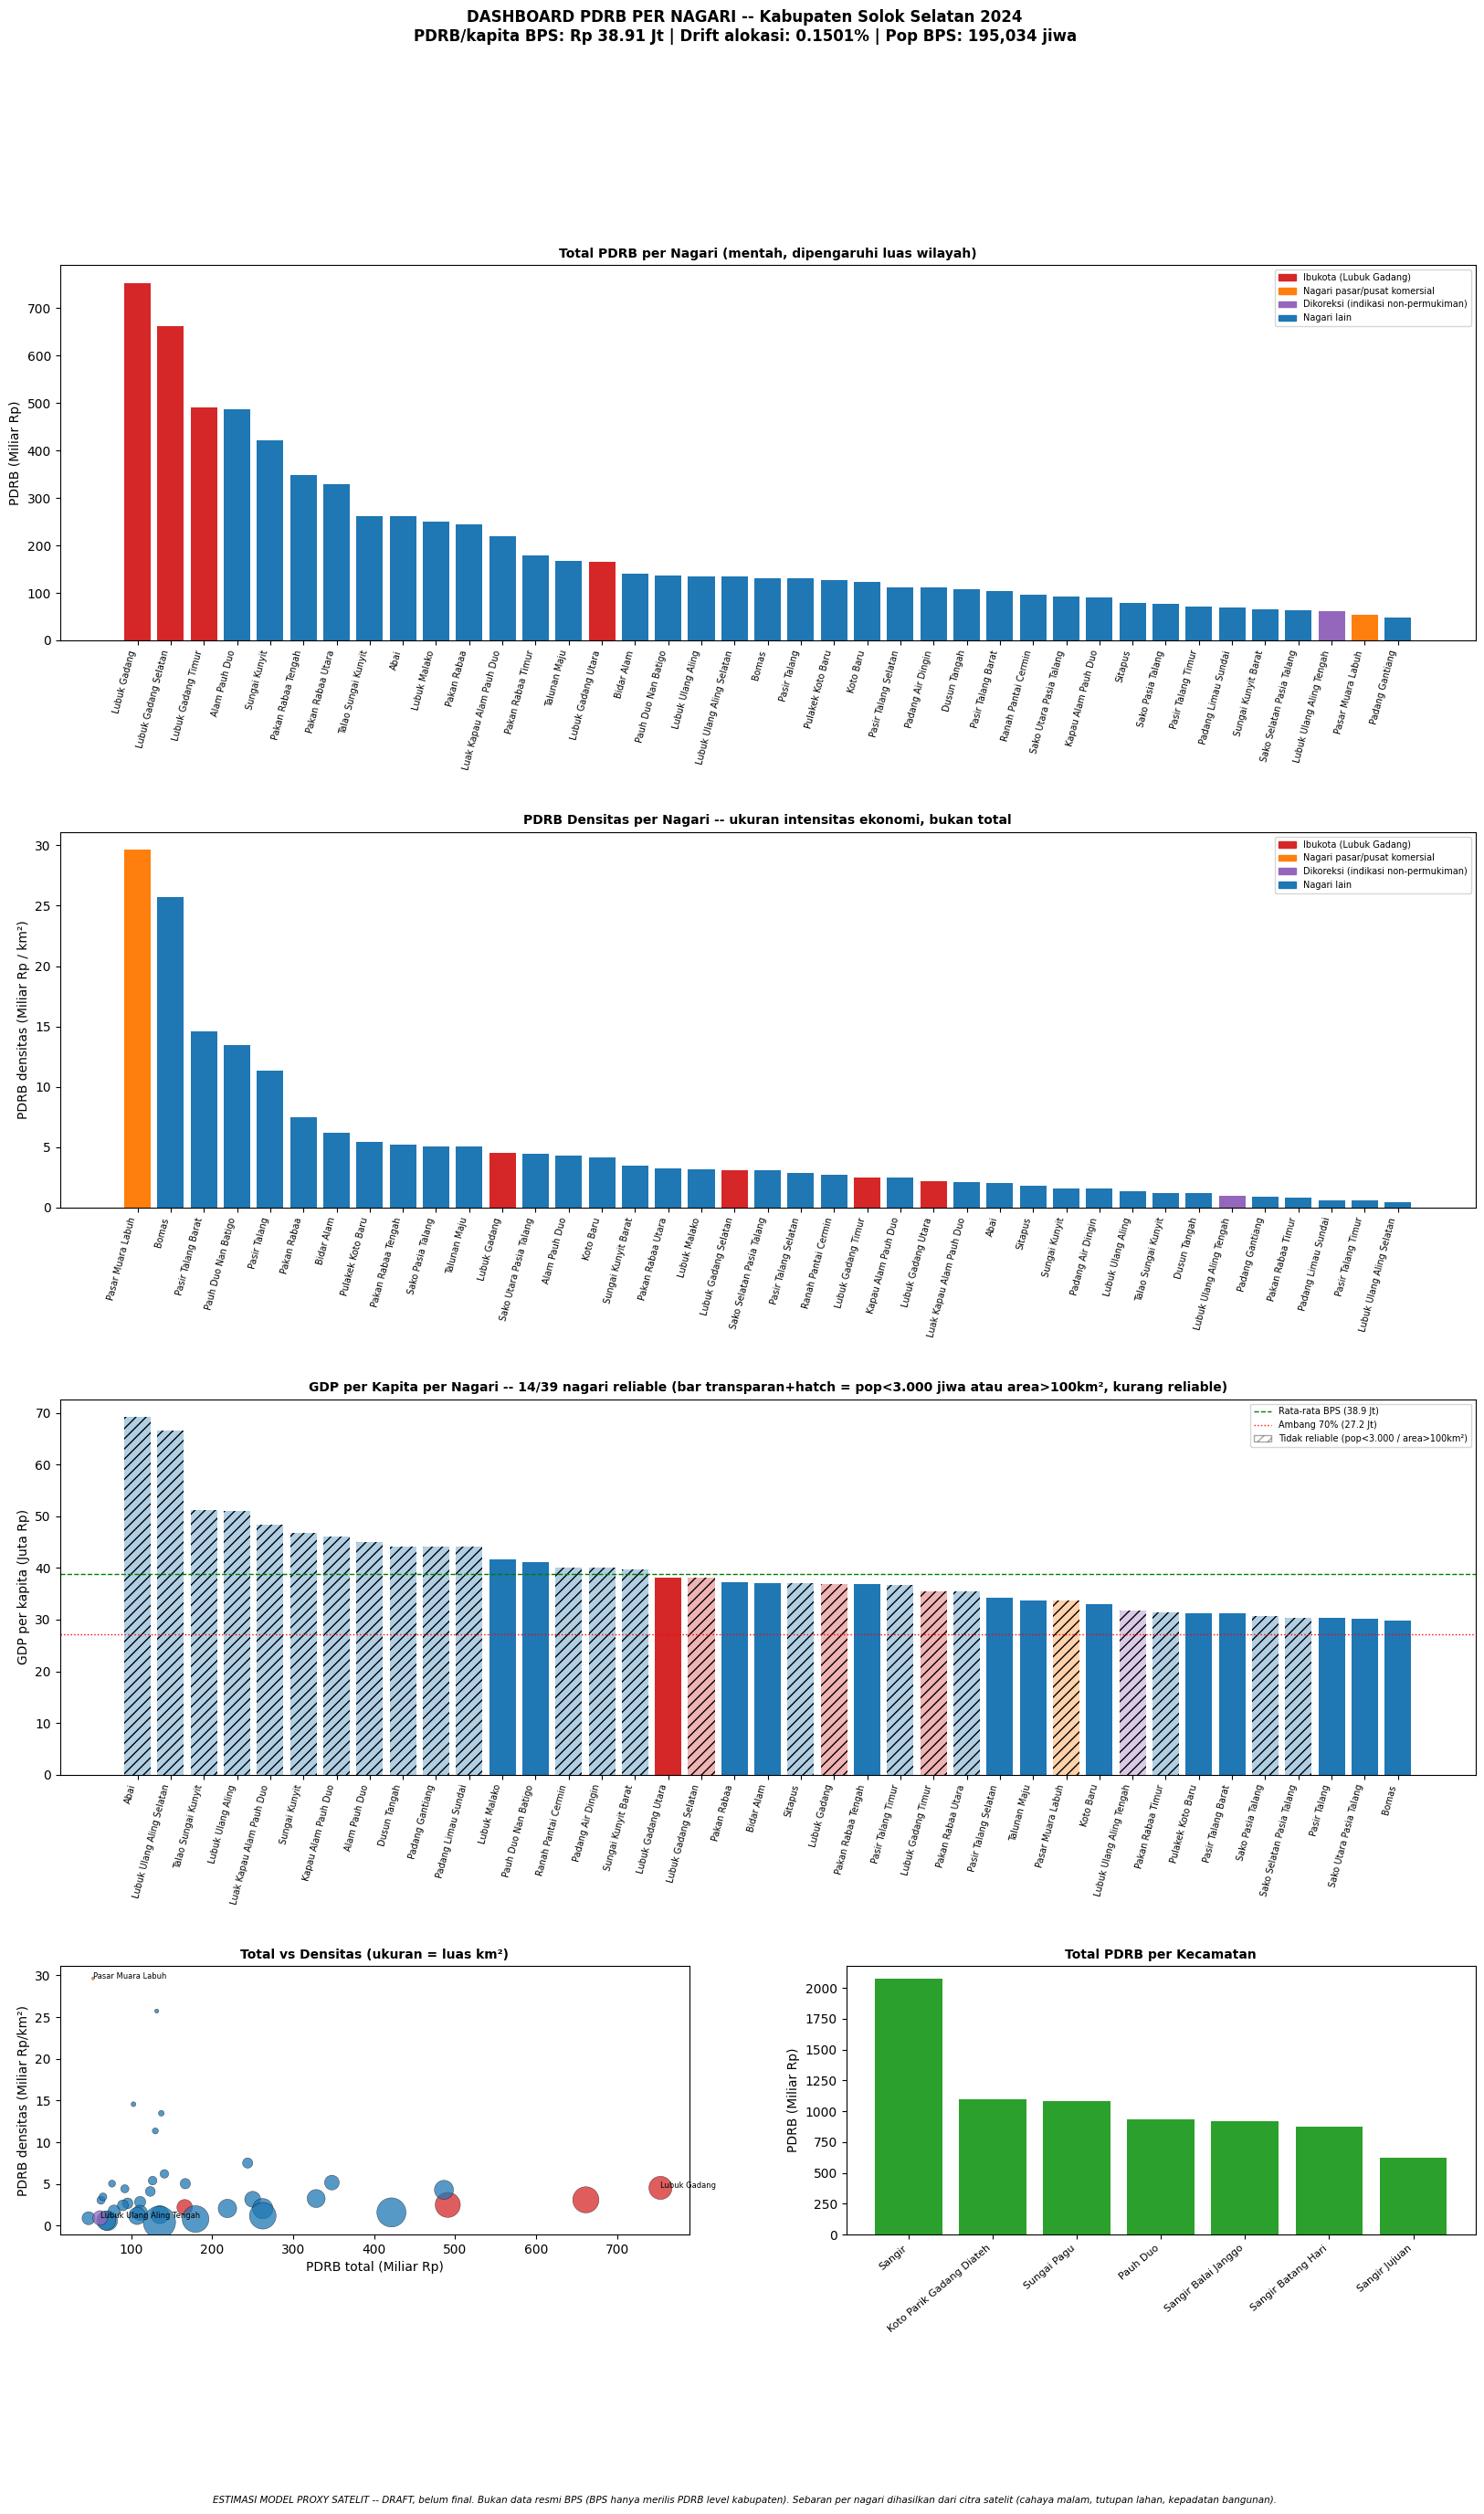


NAGARI DENGAN SELISIH RANK TERBESAR (kecil di total, padat di densitas)
                   nagari           kecamatan  pdrb_miliar  pdrb_density  rank_total  rank_densitas  selisih_rank
        Pasar Muara Labuh         Sungai Pagu    53.023079     29.621832          38              1            37
       Pasir Talang Barat         Sungai Pagu   102.965419     14.563708          27              3            24
        Sako Pasia Talang         Sungai Pagu    76.494371      5.049133          32             10            22
      Sungai Kunyit Barat Sangir Balai Janggo    65.288308      3.469092          35             16            19
                    Bomas         Sungai Pagu   131.692924     25.721274          20              2            18
Sako Selatan Pasia Talang         Sungai Pagu    62.876526      3.062666          36             20            16
  Sako Utara Pasia Talang         Sungai Pagu    92.310286      4.429476          29             13            16
             Pa

In [19]:
# ── DASHBOARD GDP PER NAGARI v2 (+ panel PDRB densitas) ────────
df['pdrb_density'] = df['pdrb_miliar'] / df['area_km2'].replace(0, np.nan)

fig = plt.figure(figsize=(20, 28))
gs = fig.add_gridspec(4, 2, hspace=0.55, wspace=0.25,
                       height_ratios=[1.4, 1.4, 1.4, 1])

fig.suptitle(
    "DASHBOARD PDRB PER NAGARI -- Kabupaten Solok Selatan 2024\n"
    f"PDRB/kapita BPS: Rp {PDRB_KAPITA_2024/1e6:.2f} Jt | "
    f"Drift alokasi: {drift_df:.4f}% | Pop BPS: {POP_BPS_2024:,} jiwa",
    fontsize=12, fontweight='bold'
)

def warna_nagari(nama):
    if 'Lubuk Gadang' in nama:
        return '#d62728'
    elif 'Muara Labuh' in nama or 'Pasar' in nama:
        return '#ff7f0e'
    elif 'perlu_koreksi' in df.columns and nama in df.loc[df['perlu_koreksi'], 'nagari'].values:
        return '#9467bd'
    else:
        return '#1f77b4'

legend1 = [
    mpatches.Patch(color='#d62728', label='Ibukota (Lubuk Gadang)'),
    mpatches.Patch(color='#ff7f0e', label='Nagari pasar/pusat komersial'),
    mpatches.Patch(color='#9467bd', label='Dikoreksi (indikasi non-permukiman)'),
    mpatches.Patch(color='#1f77b4', label='Nagari lain'),
]

# 1. Total PDRB per nagari -------------------------------------------------
ax1 = fig.add_subplot(gs[0, :])
df_sorted = df.sort_values('pdrb_miliar', ascending=False).reset_index(drop=True)
ax1.bar(range(len(df_sorted)), df_sorted['pdrb_miliar'],
        color=[warna_nagari(n) for n in df_sorted['nagari']])
ax1.set_xticks(range(len(df_sorted)))
ax1.set_xticklabels(df_sorted['nagari'], rotation=75, ha='right', fontsize=7)
ax1.set_ylabel('PDRB (Miliar Rp)')
ax1.set_title('Total PDRB per Nagari (mentah, dipengaruhi luas wilayah)', fontsize=10, fontweight='bold')
ax1.legend(handles=legend1, loc='upper right', fontsize=7)

# 2. PDRB DENSITAS per nagari (panel baru) --------------------------------
ax2 = fig.add_subplot(gs[1, :])
df_dens = df.sort_values('pdrb_density', ascending=False).reset_index(drop=True)
ax2.bar(range(len(df_dens)), df_dens['pdrb_density'],
        color=[warna_nagari(n) for n in df_dens['nagari']])
ax2.set_xticks(range(len(df_dens)))
ax2.set_xticklabels(df_dens['nagari'], rotation=75, ha='right', fontsize=7)
ax2.set_ylabel('PDRB densitas (Miliar Rp / km²)')
ax2.set_title('PDRB Densitas per Nagari -- ukuran intensitas ekonomi, bukan total',
              fontsize=10, fontweight='bold')
ax2.legend(handles=legend1, loc='upper right', fontsize=7)

# 3. GDP per kapita (SEMUA nagari ditampilkan, yang tidak reliable ditandai)
ax3 = fig.add_subplot(gs[2, :])
df_kapita = df.sort_values('gdp_per_kapita_juta', ascending=False).reset_index(drop=True)
reliable_mask = (df_kapita['pop_kalib'] > 3000) & (df_kapita['area_km2'] < 100)
n_reliable = int(reliable_mask.sum())

bars3 = ax3.bar(range(len(df_kapita)), df_kapita['gdp_per_kapita_juta'],
                 color=[warna_nagari(n) for n in df_kapita['nagari']])
for bar, rel in zip(bars3, reliable_mask):
    if not rel:
        # nagari dengan populasi kecil (<3.000 jiwa) atau area terlalu luas (>100km2):
        # GDP/kapita rawan noise -- ditandai transparan + hatch, bukan disembunyikan
        bar.set_alpha(0.35)
        bar.set_hatch('///')

ax3.axhline(PDRB_KAPITA_2024/1e6, color='green', linestyle='--', linewidth=1,
            label=f'Rata-rata BPS ({PDRB_KAPITA_2024/1e6:.1f} Jt)')
ax3.axhline(threshold_gdp/1e6, color='red', linestyle=':', linewidth=1,
            label=f'Ambang 70% ({threshold_gdp/1e6:.1f} Jt)')
ax3.set_xticks(range(len(df_kapita)))
ax3.set_xticklabels(df_kapita['nagari'], rotation=75, ha='right', fontsize=7)
ax3.set_ylabel('GDP per kapita (Juta Rp)')
ax3.set_title(
    f'GDP per Kapita per Nagari -- {n_reliable}/{len(df_kapita)} nagari reliable '
    '(bar transparan+hatch = pop<3.000 jiwa atau area>100km\u00b2, kurang reliable)',
    fontsize=10, fontweight='bold'
)
legend3 = [
    Line2D([0], [0], color='green', linestyle='--', linewidth=1, label=f'Rata-rata BPS ({PDRB_KAPITA_2024/1e6:.1f} Jt)'),
    Line2D([0], [0], color='red', linestyle=':', linewidth=1, label=f'Ambang 70% ({threshold_gdp/1e6:.1f} Jt)'),
    mpatches.Patch(facecolor='white', edgecolor='black', hatch='///', alpha=0.35, label='Tidak reliable (pop<3.000 / area>100km\u00b2)'),
]
ax3.legend(handles=legend3, fontsize=7)

# 4a. Scatter total vs densitas -- lihat siapa "kecil tapi padat" ----------
ax4 = fig.add_subplot(gs[3, 0])
ax4.scatter(df['pdrb_miliar'], df['pdrb_density'],
            c=[warna_nagari(n) for n in df['nagari']],
            s=df['area_km2'].clip(lower=2) * 2, alpha=0.75, edgecolor='k', linewidth=0.3)
for _, r in df.iterrows():
    if r['nagari'] in ['Lubuk Gadang', 'Pasar Muara Labuh'] or (
        'perlu_koreksi' in df.columns and r.get('perlu_koreksi', False)):
        ax4.annotate(r['nagari'], (r['pdrb_miliar'], r['pdrb_density']), fontsize=6)
ax4.set_xlabel('PDRB total (Miliar Rp)')
ax4.set_ylabel('PDRB densitas (Miliar Rp/km²)')
ax4.set_title('Total vs Densitas (ukuran = luas km²)', fontsize=10, fontweight='bold')

# 4b. Total PDRB per kecamatan ---------------------------------------------
ax5 = fig.add_subplot(gs[3, 1])
df_kec = df.groupby('kecamatan')['pdrb_miliar'].sum().sort_values(ascending=False)
ax5.bar(df_kec.index, df_kec.values, color='#2ca02c')
ax5.set_xticklabels(df_kec.index, rotation=40, ha='right', fontsize=8)
ax5.set_ylabel('PDRB (Miliar Rp)')
ax5.set_title('Total PDRB per Kecamatan', fontsize=10, fontweight='bold')

plt.figtext(0.5, 0.005,
    "ESTIMASI MODEL PROXY SATELIT -- DRAFT, belum final. "
    "Bukan data resmi BPS (BPS hanya merilis PDRB level kabupaten). "
    "Sebaran per nagari dihasilkan dari citra satelit (cahaya malam, tutupan lahan, kepadatan bangunan).",
    ha='center', fontsize=7.5, style='italic')

plt.tight_layout(rect=[0, 0.02, 1, 0.97])
plt.savefig('dashboard_pdrb_nagari_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Tabel ringkas: bandingkan rank total vs rank densitas -----------------
df['rank_total']   = df['pdrb_miliar'].rank(ascending=False).astype(int)
df['rank_densitas'] = df['pdrb_density'].rank(ascending=False).astype(int)
df['selisih_rank'] = df['rank_total'] - df['rank_densitas']

print(f"\n{'='*80}\nNAGARI DENGAN SELISIH RANK TERBESAR (kecil di total, padat di densitas)\n{'='*80}")
cols_r = ['nagari','kecamatan','pdrb_miliar','pdrb_density','rank_total','rank_densitas','selisih_rank']
print(df.sort_values('selisih_rank', ascending=False)[cols_r].head(10).to_string(index=False))

In [20]:
cols_cek = ['nagari','kecamatan','area_km2','pop_hrsl','pop_kalib',
            'bangunan_density','ntl_mean','pdrb_G','pdrb_A','pdrb_miliar',
            'gdp_per_kapita_juta']
nagari_pasar = ['Pasar Muara Labuh','Pasir Talang Barat','Bomas',
                'Koto Baru','Pasir Talang Selatan','Sungai Kunyit Barat']
print(df[df['nagari'].isin(nagari_pasar)][cols_cek].to_string(index=False))

              nagari           kecamatan  area_km2  pop_hrsl   pop_kalib  bangunan_density  ntl_mean    pdrb_G    pdrb_A  pdrb_miliar  gdp_per_kapita_juta
               Bomas         Sungai Pagu      5.12    2993.0 4406.959852        161.279155  0.686541 35.136360 24.051776   131.692924            29.882942
           Koto Baru         Sungai Pagu     30.07    2543.0 3744.369831         33.154068  0.379444 37.126366  7.678699   123.778388            33.057201
   Pasar Muara Labuh         Sungai Pagu      1.79    1069.0 1574.019406        276.780930  1.196542 17.559575  1.164084    53.023079            33.686420
  Pasir Talang Barat         Sungai Pagu      7.07    2234.0 3289.391349         97.773121  0.532760 30.939341 10.501195   102.965419            31.302271
Pasir Talang Selatan         Sungai Pagu     38.99    2204.0 3245.218681         19.032760  0.338281 32.326034  9.863151   111.187884            34.262062
 Sungai Kunyit Barat Sangir Balai Janggo     18.82    1529.0 1641.5930

In [21]:
sektor_all = ['pdrb_'+k for k in pdrb_images.keys()]
print(df[df['nagari']=='Pasar Muara Labuh'][['nagari']+sektor_all].to_string(index=False))

           nagari   pdrb_A   pdrb_B   pdrb_C   pdrb_D   pdrb_E    pdrb_F    pdrb_G   pdrb_H   pdrb_I   pdrb_J  pdrb_K   pdrb_L  pdrb_MN   pdrb_O   pdrb_P   pdrb_Q  pdrb_RSTU
Pasar Muara Labuh 1.164084 0.527687 3.387415 0.041851 0.034691 10.244962 17.559575 5.207147 0.707341 4.500449 0.63713 0.673977 0.011778 4.076683 1.975649 1.107156   1.165502


## 10. VALIDASI RINGKAS


In [23]:
# ── 10. VALIDASI RINGKAS ─────────────────────────────────────
def is_ibukota(nama):
    return str(nama).strip().lower() == 'lubuk gadang'

def is_muara_labuh(nama):
    return 'muara labuh' in str(nama).strip().lower()

lb = df[df['nagari'].apply(is_ibukota)].iloc[0]
pm = df[df['nagari'].apply(is_muara_labuh)].iloc[0]

print(f"\n{'='*55}")
print(f"  VALIDASI v11")
print(f"  Drift        : {drift_df:.6f}%")
print(f"  Lubuk Gadang : PDRB Rp {lb['pdrb_miliar']:.1f}M | "
      f"B rank {int(df['pdrb_B'].rank(ascending=False)[lb.name])}/39 | "
      f"G rank {int(df['pdrb_G'].rank(ascending=False)[lb.name])}/39")
print(f"  Pasar Muara Labuh: PDRB Rp {pm['pdrb_miliar']:.1f}M | "
      f"B rank {int(df['pdrb_B'].rank(ascending=False)[pm.name])}/39 | "
      f"G rank {int(df['pdrb_G'].rank(ascending=False)[pm.name])}/39")
print(f"{'='*55}")

# [v12 BARU] Loop cepat rank sektor B untuk seluruh nagari referensi
print("\n[v12] Rank sektor B untuk nagari referensi (lihat Section 13 untuk detail):")
ref_all = PETI_CONFIRMED + PETI_COMPARISON
b_rank_all = df['pdrb_B'].rank(ascending=False)
for nm in ref_all:
    match = df[df['nagari'] == nm]
    tag = '[PETI]' if nm in PETI_CONFIRMED else '[pembanding]'
    if match.empty:
        print(f"  {tag:14s} {nm:28s} -> TIDAK DITEMUKAN di df (cek ejaan nama nagari)")
        continue
    idx = match.index[0]
    print(f"  {tag:14s} {nm:28s} -> pdrb_B = Rp {df.loc[idx,'pdrb_B']:.3f}M | rank {int(b_rank_all[idx])}/{len(df)}")



  VALIDASI v11
  Drift        : 0.150145%
  Lubuk Gadang : PDRB Rp 753.5M | B rank 7/39 | G rank 1/39
  Pasar Muara Labuh: PDRB Rp 53.0M | B rank 39/39 | G rank 29/39

[v12] Rank sektor B untuk nagari referensi (lihat Section 13 untuk detail):
  [PETI]         Lubuk Ulang Aling            -> pdrb_B = Rp 40.853M | rank 6/39
  [PETI]         Lubuk Ulang Aling Selatan    -> pdrb_B = Rp 72.787M | rank 1/39
  [PETI]         Pakan Rabaa                  -> pdrb_B = Rp 10.154M | rank 22/39
  [PETI]         Pakan Rabaa Tengah           -> pdrb_B = Rp 15.179M | rank 17/39
  [PETI]         Pakan Rabaa Timur            -> pdrb_B = Rp 18.121M | rank 14/39
  [PETI]         Lubuk Gadang                 -> pdrb_B = Rp 33.730M | rank 7/39
  [PETI]         Lubuk Gadang Selatan         -> pdrb_B = Rp 41.489M | rank 4/39
  [pembanding]   Pakan Rabaa Utara            -> pdrb_B = Rp 12.906M | rank 19/39


## 11. DASHBOARD v13 (MapBiomas)\n

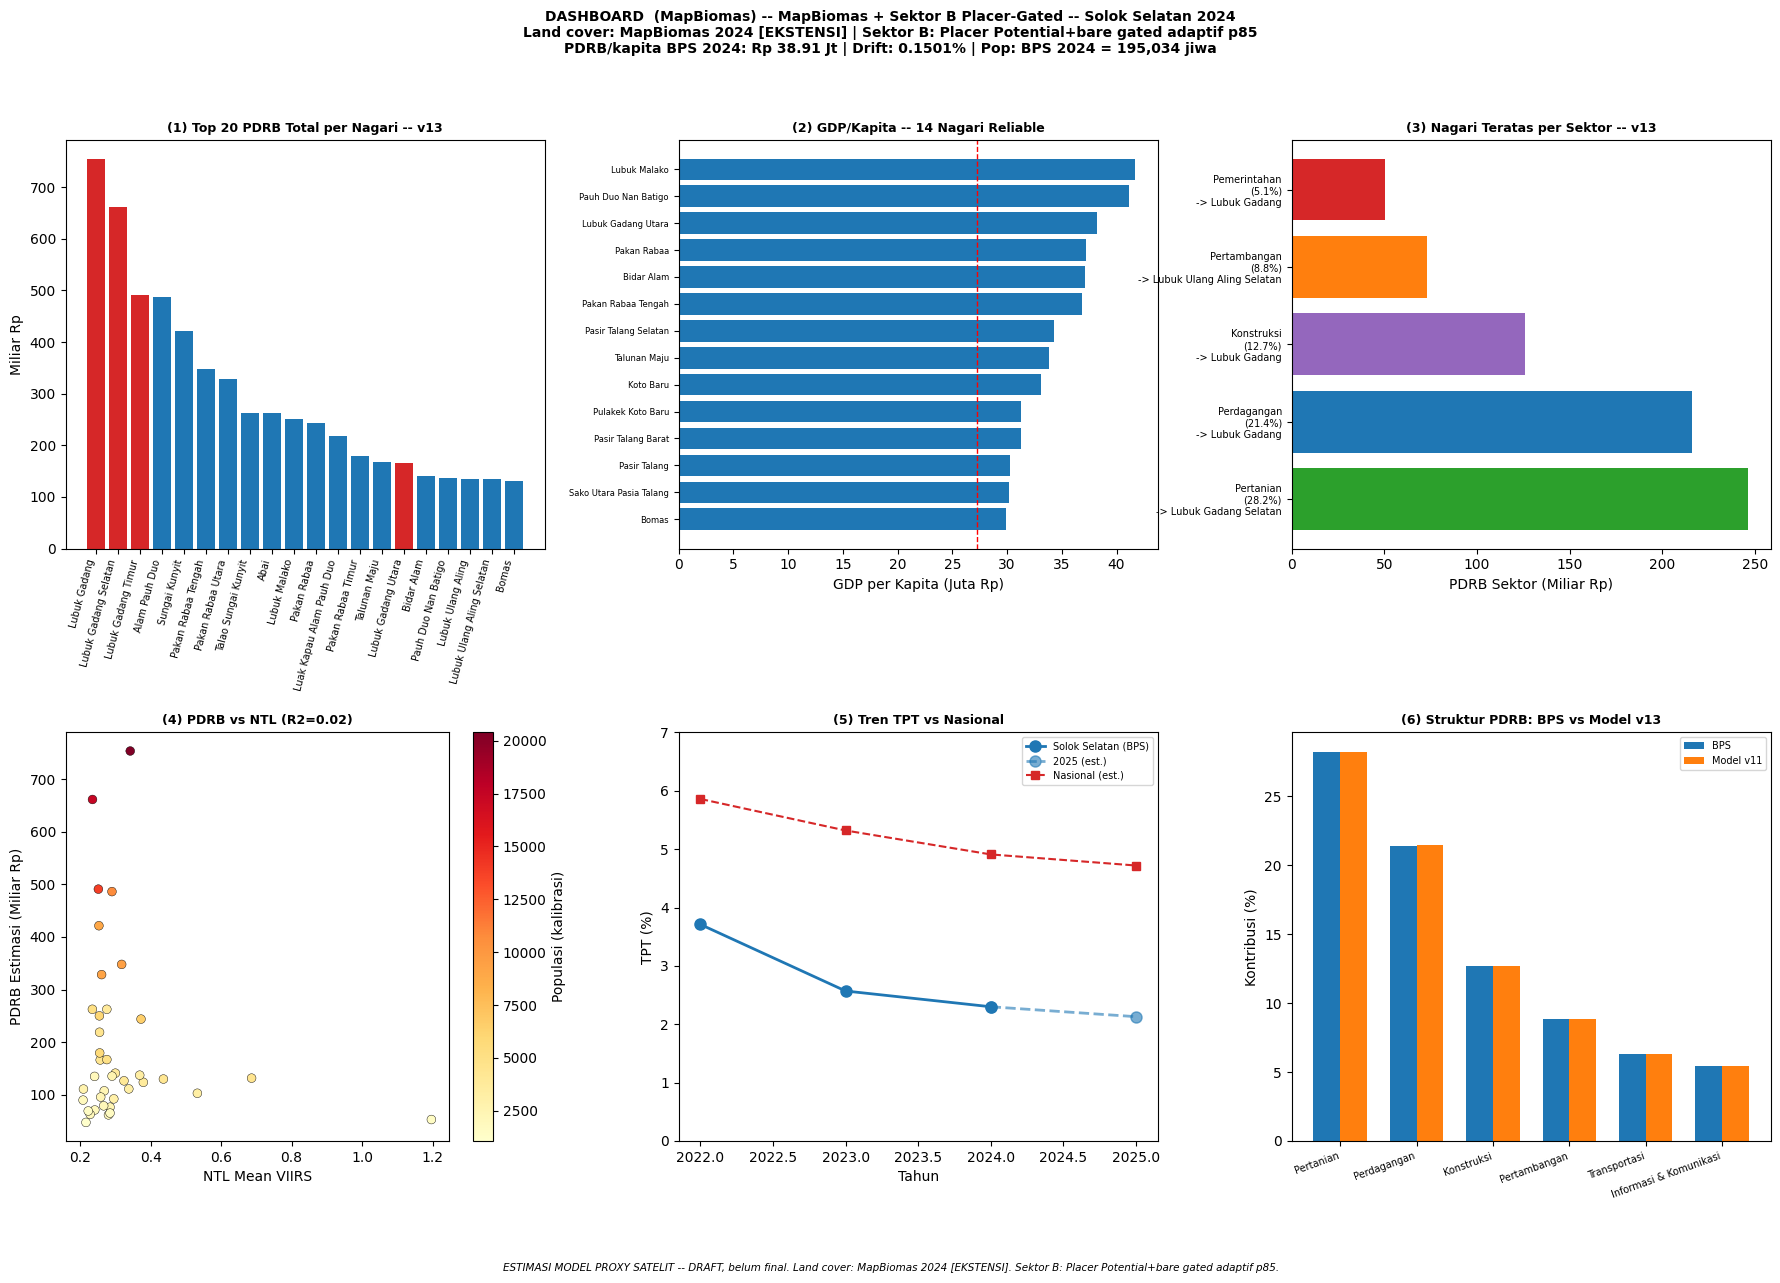

Dashboard v13 draft tersimpan: /content/dashboard_v13_draft.png


In [24]:
# ── 11. DASHBOARD v11 ─────────────────────────────────────────
tpt_tahun      = [2022, 2023, 2024, 2025]
tpt_solsel     = [3.71, 2.57, 2.30, 2.13]
tpt_nasional   = [5.86, 5.32, 4.91, 4.72]
sektor_names = {
    'A': 'Pertanian', 'B': 'Pertambangan', 'C': 'Industri', 'D': 'Listrik & Gas',
    'E': 'Air & Limbah', 'F': 'Konstruksi', 'G': 'Perdagangan', 'H': 'Transportasi',
    'I': 'Akomodasi & Makan', 'J': 'Informasi & Komunikasi', 'K': 'Jasa Keuangan',
    'L': 'Real Estate', 'MN': 'Jasa Perusahaan', 'O': 'Pemerintahan',
    'P': 'Pendidikan', 'Q': 'Kesehatan', 'RSTU': 'Jasa Lainnya',
}
kontribusi_pct = {k: targets[f'pdrb_{k}'] / TOTAL_BPS * 100 for k in pdrb_images.keys()}

def top_nagari_untuk_sektor(kode):
    col = f'pdrb_{kode}'
    row = df.loc[df[col].idxmax()]
    return row['nagari'], row[col]

fig = plt.figure(figsize=(22, 13))
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.28)

lulc_label = f'MapBiomas {LULC_YEAR} [EKSTENSI]' if USE_MAPBIOMAS else 'Dynamic World [v10 fallback]'
sektor_b_label = (f'Placer Potential+bare gated adaptif p{PLACER_GATE_PERCENTILE}' if USE_PLACER_POTENTIAL
                   else 'bare-gated, built dihapus [FIX v11]' if USE_SECTOR_B_FIX
                   else 'formula asli Firman (built termasuk)')
fig.suptitle(
    "DASHBOARD  (MapBiomas) -- MapBiomas + Sektor B Placer-Gated -- Solok Selatan 2024\n"
    f"Land cover: {lulc_label} | Sektor B: {sektor_b_label}\n"
    f"PDRB/kapita BPS 2024: Rp {PDRB_KAPITA_2024/1e6:.2f} Jt | Drift: {drift_df:.4f}% | "
    f"Pop: BPS 2024 = {POP_BPS_2024:,} jiwa",
    fontsize=10, fontweight='bold'
)

ax1 = fig.add_subplot(gs[0, 0])
df_sorted = df.sort_values('pdrb_miliar', ascending=False).head(20).reset_index(drop=True)
colors1 = ['#d62728' if 'Lubuk Gadang' in n else '#ff7f0e' if 'Pasar Muara Labuh' in n else '#1f77b4'
           for n in df_sorted['nagari']]
bars1 = ax1.bar(range(len(df_sorted)), df_sorted['pdrb_miliar'], color=colors1)
ax1.set_xticks(range(len(df_sorted)))
ax1.set_xticklabels(df_sorted['nagari'], rotation=75, ha='right', fontsize=7)
ax1.set_ylabel("Miliar Rp")
ax1.set_title("(1) Top 20 PDRB Total per Nagari -- v13", fontsize=9, fontweight='bold')

ax2 = fig.add_subplot(gs[0, 1])
reliable = df[(df['pop_kalib'] > 3000) & (df['area_km2'] < 100)].copy()
reliable = reliable.sort_values('gdp_per_kapita_juta', ascending=True)
colors2 = ['#d62728' if v < threshold_gdp/1e6 else '#1f77b4' for v in reliable['gdp_per_kapita_juta']]
ax2.barh(reliable['nagari'], reliable['gdp_per_kapita_juta'], color=colors2)
ax2.axvline(threshold_gdp/1e6, color='red', linestyle='--', linewidth=1)
ax2.set_xlabel("GDP per Kapita (Juta Rp)")
ax2.set_title(f"(2) GDP/Kapita -- {len(reliable)} Nagari Reliable", fontsize=9, fontweight='bold')
ax2.tick_params(axis='y', labelsize=6)

ax3 = fig.add_subplot(gs[0, 2])
sektor_order = ['A', 'G', 'F', 'B', 'O']
sek_colors = {'A': '#2ca02c', 'G': '#1f77b4', 'F': '#9467bd', 'B': '#ff7f0e', 'O': '#d62728'}
vals, labels_bar = [], []
for kode in sektor_order:
    nagari_top, val = top_nagari_untuk_sektor(kode)
    vals.append(val)
    labels_bar.append(f"{sektor_names[kode]}\n({kontribusi_pct[kode]:.1f}%)\n-> {nagari_top}")
ax3.barh(range(len(sektor_order)), vals, color=[sek_colors[k] for k in sektor_order])
ax3.set_yticks(range(len(sektor_order)))
ax3.set_yticklabels(labels_bar, fontsize=7)
ax3.set_xlabel("PDRB Sektor (Miliar Rp)")
ax3.set_title("(3) Nagari Teratas per Sektor -- v13", fontsize=9, fontweight='bold')

ax4 = fig.add_subplot(gs[1, 0])
sc = ax4.scatter(df['ntl_mean'], df['pdrb_miliar'], c=df['pop_kalib'], cmap='YlOrRd', s=40, edgecolors='k', linewidths=0.3)
r2 = np.corrcoef(df['ntl_mean'].fillna(0), df['pdrb_miliar'].fillna(0))[0, 1] ** 2
plt.colorbar(sc, ax=ax4, label='Populasi (kalibrasi)')
ax4.set_xlabel("NTL Mean VIIRS")
ax4.set_ylabel("PDRB Estimasi (Miliar Rp)")
ax4.set_title(f"(4) PDRB vs NTL (R2={r2:.2f})", fontsize=9, fontweight='bold')

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(tpt_tahun[:3], tpt_solsel[:3], 'o-', color='#1f77b4', linewidth=2, markersize=8, label='Solok Selatan (BPS)')
ax5.plot(tpt_tahun[2:], tpt_solsel[2:], 'o--', color='#1f77b4', linewidth=2, markersize=8, alpha=0.6, label='2025 (est.)')
ax5.plot(tpt_tahun, tpt_nasional, 's--', color='#d62728', linewidth=1.5, markersize=6, label='Nasional (est.)')
ax5.set_xlabel("Tahun")
ax5.set_ylabel("TPT (%)")
ax5.set_title("(5) Tren TPT vs Nasional", fontsize=9, fontweight='bold')
ax5.legend(fontsize=7)
ax5.set_ylim(0, 7)

ax6 = fig.add_subplot(gs[1, 2])
sektor_urut = sorted(pdrb_images.keys(), key=lambda k: targets[f'pdrb_{k}'], reverse=True)[:6]
bps_vals   = [targets[f'pdrb_{k}'] for k in sektor_urut]
model_vals = [df[f'pdrb_{k}'].sum() for k in sektor_urut]
x = np.arange(len(sektor_urut))
w = 0.35
ax6.bar(x - w/2, [v/TOTAL_BPS*100 for v in bps_vals], w, label='BPS', color='#1f77b4')
ax6.bar(x + w/2, [v/TOTAL_BPS*100 for v in model_vals], w, label='Model v11', color='#ff7f0e')
ax6.set_xticks(x)
ax6.set_xticklabels([sektor_names.get(k, k) for k in sektor_urut], rotation=20, ha='right', fontsize=7)
ax6.set_ylabel("Kontribusi (%)")
ax6.set_title("(6) Struktur PDRB: BPS vs Model v13", fontsize=9, fontweight='bold')
ax6.legend(fontsize=7)

plt.figtext(0.5, 0.01,
    "ESTIMASI MODEL PROXY SATELIT -- DRAFT, belum final. "
    f"Land cover: {lulc_label}. Sektor B: {sektor_b_label}.",
    ha='center', fontsize=7.5, style='italic')

plt.savefig('/content/dashboard_v13_draft.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard v13 draft tersimpan: /content/dashboard_v13_draft.png")

## 12. DIAGNOSTIK DENSITY (MapBiomas + Placer)\n

In [25]:
# ── 12. DIAGNOSTIK DENSITY (sekarang baku, bukan ad-hoc) ─────
print("\nMenghitung diagnostik density (built/bare per km2)...")

built_bare_stack = ee.Image.cat([
    built.rename('built_frac_zonal'),
    bare.rename('bare_frac_zonal'),
    placer_n.rename('placer_mean_zonal'),
    placer_n_final.rename('placer_clean_mean_zonal'),          # [v14]
    bare_gate_clean.rename('bare_gate_clean_frac_zonal'),       # [v14]
])
diag_fc = built_bare_stack.reduceRegions(collection=solsel, reducer=ee.Reducer.mean(), scale=SCALE, tileScale=4)
df_diag = geemap.ee_to_df(diag_fc)
df_diag = df_diag.rename(columns={COL_NAGARI: 'nagari'})

# Ambil hanya kolom yang ada (aman jika placer_n = 0 / kosong)
cols_diag_keep = ['nagari']
for c in ['built_frac_zonal', 'bare_frac_zonal', 'placer_mean_zonal', 'placer_clean_mean_zonal', 'bare_gate_clean_frac_zonal']:
    if c in df_diag.columns:
        cols_diag_keep.append(c)
    else:
        print(f"  ⚠ kolom {c} tidak ada di hasil reduceRegions mean")
        df_diag[c] = 0.0
        cols_diag_keep.append(c)
df_diag = df_diag[cols_diag_keep]

# p90 dan max placer — dipisah biar nama kolom GEE pasti jelas
placer_p90_fc = placer_n.rename('placer_p90').reduceRegions(
    collection=solsel, reducer=ee.Reducer.percentile([90]), scale=SCALE, tileScale=4)
df_p90 = geemap.ee_to_df(placer_p90_fc)
df_p90 = df_p90.rename(columns={COL_NAGARI: 'nagari'})
# deteksi nama kolom percentile (bisa 'placer_p90' atau 'p90' tergantung versi)
p90_col = None
for c in df_p90.columns:
    if c != 'nagari' and ('p90' in c.lower() or 'percentile' in c.lower() or c == 'placer_p90'):
        p90_col = c
        break
if p90_col is None:
    # fallback: kolom numerik pertama selain nagari
    num_cols = [c for c in df_p90.columns if c != 'nagari' and pd.api.types.is_numeric_dtype(df_p90[c])]
    p90_col = num_cols[0] if num_cols else None
    print(f"  ⚠ nama kolom p90 tidak standar, kolom tersedia: {list(df_p90.columns)}")

placer_max_fc = placer_n.rename('placer_max').reduceRegions(
    collection=solsel, reducer=ee.Reducer.max(), scale=SCALE, tileScale=4)
df_max = geemap.ee_to_df(placer_max_fc)
df_max = df_max.rename(columns={COL_NAGARI: 'nagari'})
max_col = None
for c in df_max.columns:
    if c != 'nagari' and ('max' in c.lower() or c == 'placer_max'):
        max_col = c
        break
if max_col is None:
    num_cols = [c for c in df_max.columns if c != 'nagari' and pd.api.types.is_numeric_dtype(df_max[c])]
    max_col = num_cols[0] if num_cols else None
    print(f"  ⚠ nama kolom max tidak standar, kolom tersedia: {list(df_max.columns)}")

df_placer_extra = df_p90[['nagari']].copy()
df_placer_extra['placer_p90_zonal'] = df_p90[p90_col].values if p90_col else 0.0
df_placer_extra['placer_max_zonal'] = df_max[max_col].values if max_col else 0.0

df_diag = df_diag.merge(df_placer_extra, on='nagari', how='left')

df_full = df.merge(df_diag, on='nagari', how='left')
df_full['built_area_km2'] = df_full['built_frac_zonal'] * df_full['area_km2']
df_full['bare_area_km2']  = df_full['bare_frac_zonal']  * df_full['area_km2']
df_full['pdrb_density_total'] = df_full['pdrb_miliar'] / df_full['area_km2']
df_full['pdrb_G_density']     = df_full['pdrb_G'] / df_full['area_km2']
df_full['pdrb_B_density']     = df_full['pdrb_B'] / df_full['area_km2']

# gate pass — aman jika placer tidak aktif
if USE_PLACER_POTENTIAL:
    try:
        gate_thr = float(placer_gate_val.getInfo())
    except Exception:
        gate_thr = 999.0
    df_full['placer_gate_pass'] = df_full['placer_max_zonal'] > gate_thr
else:
    df_full['placer_gate_pass'] = False

cols_G = ['nagari', 'area_km2', 'built_area_km2', 'pop_kalib', 'ntl_mean', 'pdrb_G', 'pdrb_G_density']
cols_B = ['nagari', 'area_km2', 'bare_area_km2', 'built_area_km2', 'ntl_mean',
          'placer_mean_zonal', 'placer_clean_mean_zonal', 'placer_p90_zonal', 'placer_max_zonal',
          'placer_gate_pass', 'pdrb_B', 'pdrb_B_density']

# pastikan semua kolom ada
for c in cols_G + cols_B:
    if c not in df_full.columns:
        df_full[c] = 0.0

print("\n=== SEKTOR G (Perdagangan) -- Top 8 TOTAL vs Top 8 DENSITAS ===")
print("\n-- Top 8 TOTAL --")
print(df_full[cols_G].sort_values('pdrb_G', ascending=False).head(8).to_string(index=False))
print("\n-- Top 8 DENSITAS --")
print(df_full[cols_G].sort_values('pdrb_G_density', ascending=False).head(8).to_string(index=False))

print("\n\n=== SEKTOR B (Pertambangan) -- Top 8 TOTAL vs Top 8 DENSITAS ===")
print("\n-- Top 8 TOTAL --")
print(df_full[cols_B].sort_values('pdrb_B', ascending=False).head(8).to_string(index=False))
print("\n-- Top 8 DENSITAS --")
print(df_full[cols_B].sort_values('pdrb_B_density', ascending=False).head(8).to_string(index=False))

print("\n\n=== CEK SPESIFIK: Pasar Muara Labuh vs Lubuk Gadang vs Lubuk Ulang Aling ===")
check_names = df_full['nagari'].str.contains('Muara Labuh|Lubuk Gadang|Lubuk Ulang Aling|Pakan Rabaa', case=False, na=False)
print(df_full.loc[check_names, ['nagari','area_km2','built_area_km2','bare_area_km2',
                                  'placer_mean_zonal','placer_max_zonal','placer_gate_pass','ntl_mean',
                                  'pdrb_G','pdrb_G_density','pdrb_B','pdrb_B_density']].to_string(index=False))

df_full.to_csv('/content/PDRB_v13_MapBiomas.csv', index=False)
print("\nCSV draft tersimpan: /content/PDRB_v13_MapBiomas.csv")
print("\n=== INI DRAFT -- bandingkan angka sektor B di atas ===")
print("Kalau Lubuk Gadang masih dominan di top-8 total sektor B padahal bare/placer rendah,")
print("berarti formula B masih bocor ke pusat kota -- perlu cek ulang gate / bobot.")



Menghitung diagnostik density (built/bare per km2)...

=== SEKTOR G (Perdagangan) -- Top 8 TOTAL vs Top 8 DENSITAS ===

-- Top 8 TOTAL --
              nagari  area_km2  built_area_km2    pop_kalib  ntl_mean     pdrb_G  pdrb_G_density
        Lubuk Gadang    166.00        5.184620 20386.926744  0.342315 216.000467        1.301208
Lubuk Gadang Selatan    212.76        2.279791 17374.646237  0.235278 126.656550        0.595302
  Lubuk Gadang Timur    195.92        2.576406 13827.590224  0.251930 104.972330        0.535792
  Pakan Rabaa Tengah     67.27        1.669976  9450.736271  0.318037  91.689182        1.363003
       Alam Pauh Duo    112.97        1.469263 10802.654172  0.290505  78.131519        0.691613
       Sungai Kunyit    263.60        1.423972  9006.752449  0.253486  67.430725        0.255807
         Pakan Rabaa     32.47        1.280561  6559.528498  0.372922  67.080528        2.065923
   Pakan Rabaa Utara    100.78        1.398811  9276.941042  0.261130  61.395768     

## 13. VALIDASI SEKTOR B vs PETI TERKONFIRMASI [v13]\n


Validasi sektor B vs referensi lapangan (PETI_CONFIRMED vs PETI_COMPARISON)...
                   nagari                kecamatan  area_km2  bare_area_km2  placer_mean_zonal  placer_p90_zonal  placer_max_zonal  placer_gate_pass    pdrb_B  pdrb_B_density                            status  rank_TOTAL  rank_DENSITAS
        Lubuk Ulang Aling       Sangir Batang Hari    102.05       0.191071           0.229514          0.412165          0.959290              True 40.853201        0.400325                 PETI (konfirmasi)         6.0            2.0
              Pakan Rabaa Koto Parik Gadang Diateh     32.47       0.006284           0.190966          0.364268          0.496825              True 10.153701        0.312710                 PETI (konfirmasi)        22.0            7.0
       Pakan Rabaa Tengah Koto Parik Gadang Diateh     67.27       0.000000           0.160969          0.349464          0.793675              True 15.179119        0.225645                 PETI (konfirmasi)    

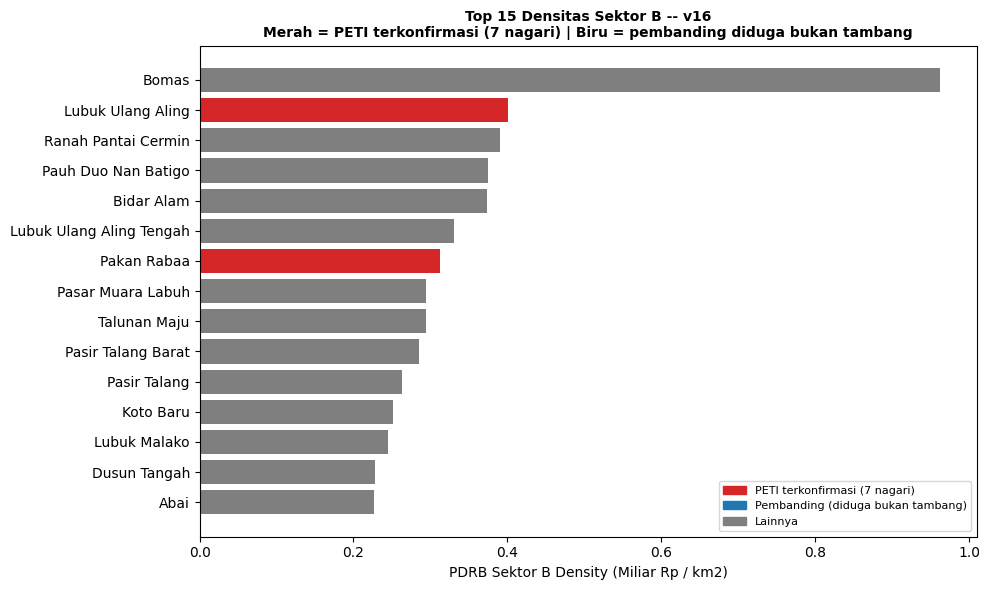


Validasi sektor B tersimpan: /content/dashboard_v16_sektorB_validation.png


In [26]:
# ── 13. VALIDASI SEKTOR B vs PETI TERKONFIRMASI [FIX v16] ────
# PERINGATAN: PETI_CONFIRMED & PETI_COMPARISON (Section 2) berasal dari
# cross-check berita + konfirmasi lapangan langsung dari peneliti (bukan
# basis data resmi/survei formal). Perlakukan sebagai indikasi arah.
print("\nValidasi sektor B vs referensi lapangan (PETI_CONFIRMED vs PETI_COMPARISON)...")

val_cols = ['nagari', 'kecamatan', 'area_km2', 'bare_area_km2',
            'placer_mean_zonal', 'placer_p90_zonal', 'placer_max_zonal', 'placer_gate_pass',
            'pdrb_B', 'pdrb_B_density']
ref_names = PETI_CONFIRMED + PETI_COMPARISON
df_val = df_full[df_full['nagari'].isin(ref_names)][val_cols].copy()
df_val['status'] = df_val['nagari'].apply(lambda n: 'PETI (konfirmasi)' if n in PETI_CONFIRMED else 'pembanding (diduga bukan tambang)')

# [FIX] dua rank terpisah, jangan dicampur jadi satu kolom ambigu
df_val['rank_TOTAL']    = df_full['pdrb_B'].rank(ascending=False)[df_full['nagari'].isin(ref_names)]
df_val['rank_DENSITAS'] = df_full['pdrb_B_density'].rank(ascending=False)[df_full['nagari'].isin(ref_names)]
print(df_val.sort_values('pdrb_B_density', ascending=False).to_string(index=False))

n_missing = set(ref_names) - set(df_val['nagari'])
if n_missing:
    print(f"\n  !!! Nama nagari tidak ditemukan di df_full: {n_missing} -- cek ejaan/spasi di boundary asset")

# [FIX] pakai len(PETI_CONFIRMED) dinamis, bukan hardcode angka
n_confirmed = len(PETI_CONFIRMED)
top_n = 10
top_density = df_full.sort_values('pdrb_B_density', ascending=False).head(top_n)['nagari'].tolist()
top_total   = df_full.sort_values('pdrb_B', ascending=False).head(top_n)['nagari'].tolist()
hit_density = [n for n in PETI_CONFIRMED if n in top_density]
hit_total   = [n for n in PETI_CONFIRMED if n in top_total]

print(f"\nSitus PETI_CONFIRMED yang masuk top-{top_n} pdrb_B_density: "
      f"{len(hit_density)}/{n_confirmed} -> {hit_density}")
print(f"Situs PETI_CONFIRMED yang masuk top-{top_n} pdrb_B (total): "
      f"{len(hit_total)}/{n_confirmed} -> {hit_total}")

if len(hit_density) < n_confirmed / 2:
    print("  -> Densitas: masih kurang meyakinkan. Kemungkinan penyebab:")
    print(f"     1) Gate p{PLACER_GATE_PERCENTILE} masih terlalu ketat untuk situs kecil (turunkan PLACER_GATE_PERCENTILE)")
    print("     2) Resolusi placer 30m tidak menangkap situs kecil (mestinya sudah lebih baik dgn dw_bare_prob v16)")
    print("     3) Koordinat situs meleset dari boundary nagari yang dipakai di sini")
else:
    print("  -> Densitas: cukup meyakinkan sebagai indikasi awal, tapi tetap bukan validasi formal.")

# Bar chart: densitas, PETI=merah, pembanding=biru, lainnya=abu-abu
fig13, ax13 = plt.subplots(figsize=(10, 6))
plot_df = df_full.sort_values('pdrb_B_density', ascending=False).head(15).copy()
colors13 = ['#d62728' if n in PETI_CONFIRMED else '#1f77b4' if n in PETI_COMPARISON else '#7f7f7f'
            for n in plot_df['nagari']]
ax13.barh(plot_df['nagari'][::-1], plot_df['pdrb_B_density'][::-1], color=colors13[::-1])
ax13.set_xlabel("PDRB Sektor B Density (Miliar Rp / km2)")
ax13.set_title(f"Top 15 Densitas Sektor B -- v16\nMerah = PETI terkonfirmasi ({n_confirmed} nagari) | Biru = pembanding diduga bukan tambang",
                fontsize=10, fontweight='bold')
legend_elems = [
    mpatches.Patch(color='#d62728', label=f'PETI terkonfirmasi ({n_confirmed} nagari)'),
    mpatches.Patch(color='#1f77b4', label='Pembanding (diduga bukan tambang)'),
    mpatches.Patch(color='#7f7f7f', label='Lainnya'),
]
ax13.legend(handles=legend_elems, fontsize=8, loc='lower right')
plt.tight_layout()
plt.savefig('/content/dashboard_v16_sektorB_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nValidasi sektor B tersimpan: /content/dashboard_v16_sektorB_validation.png")


In [27]:
kandidat = {
    'Pasia_Putih_A': (-1.302741, 101.116445),
    'Ponpes_AlFatih_B': (-1.351870, 101.002080),
}

for nama, (lat, lon) in kandidat.items():
    titik = ee.Geometry.Point([lon, lat])
    hasil = solsel.filterBounds(titik).first()
    try:
        nagari_di_titik = hasil.get(COL_NAGARI).getInfo()
    except Exception:
        nagari_di_titik = "TIDAK DITEMUKAN (di luar semua boundary nagari)"
    print(f"{nama} ({lat}, {lon}) -> {nagari_di_titik}")

Pasia_Putih_A (-1.302741, 101.116445) -> Pakan Rabaa Timur
Ponpes_AlFatih_B (-1.35187, 101.00208) -> Pakan Rabaa Timur
